In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


### Step 2: Preprocess the Data

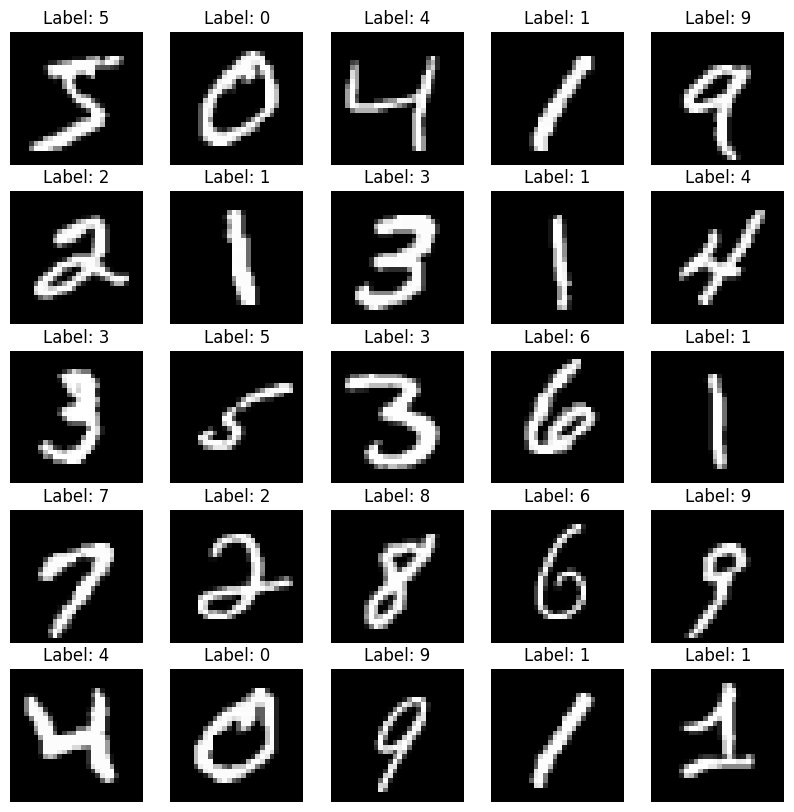

In [2]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [3]:
# Normalize the images to values between 0 and 1
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

# Reshape the images to (28, 28, 1)
x_train_reshaped = x_train_normalized.reshape(-1, 28, 28, 1)
x_test_reshaped = x_test_normalized.reshape(-1, 28, 28, 1)

# Convert the labels into one-hot encoded format
y_train_one_hot = keras.utils.to_categorical(y_train, num_classes=10)
y_test_one_hot = keras.utils.to_categorical(y_test, num_classes=10)

print(f"x_train_reshaped shape: {x_train_reshaped.shape}")
print(f"y_train_one_hot shape: {y_train_one_hot.shape}")
print(f"x_test_reshaped shape: {x_test_reshaped.shape}")
print(f"y_test_one_hot shape: {y_test_one_hot.shape}")

x_train_reshaped shape: (60000, 28, 28, 1)
y_train_one_hot shape: (60000, 10)
x_test_reshaped shape: (10000, 28, 28, 1)
y_test_one_hot shape: (10000, 10)


### Step 3: Build the CNN Model

In [4]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Step 4: Train the Model

In [6]:
history = model.fit(x_train_reshaped, y_train_one_hot,
                    epochs=10,
                    validation_data=(x_test_reshaped, y_test_one_hot),
                    batch_size=128)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.9895 - loss: 0.0333 - val_accuracy: 0.9927 - val_loss: 0.0231
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - accuracy: 0.9901 - loss: 0.0317 - val_accuracy: 0.9927 - val_loss: 0.0245
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 95ms/step - accuracy: 0.9902 - loss: 0.0306 - val_accuracy: 0.9926 - val_loss: 0.0226
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.9914 - loss: 0.0273 - val_accuracy: 0.9930 - val_loss: 0.0214
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.9915 - loss: 0.0260 - val_accuracy: 0.9930 - val_loss: 0.0214
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 94ms/step - accuracy: 0.9921 - loss: 0.0243 - val_accuracy: 0.9933 - val_loss: 0.0209
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 95ms/step - accuracy: 0.9927 - loss: 0.0235 - val_accuracy: 0.9932 - val_loss: 0.0257
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.9925 - loss: 0.0225 - 

In [5]:
history = model.fit(x_train_reshaped, y_train_one_hot,
                    epochs=10,
                    validation_data=(x_test_reshaped, y_test_one_hot),
                    batch_size=128)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 96ms/step - accuracy: 0.8997 - loss: 0.3188 - val_accuracy: 0.9776 - val_loss: 0.0689
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 96ms/step - accuracy: 0.9680 - loss: 0.1074 - val_accuracy: 0.9839 - val_loss: 0.0436
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 93ms/step - accuracy: 0.9760 - loss: 0.0810 - val_accuracy: 0.9890 - val_loss: 0.0325
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 95ms/step - accuracy: 0.9795 - loss: 0.0673 - val_accuracy: 0.9894 - val_loss: 0.0305
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 95ms/step - accuracy: 0.9825 - loss: 0.0579 - val_accuracy: 0.9903 - val_loss: 0.0270
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 100ms/step - accuracy: 0.9841 - loss: 0.0533 - val_accuracy: 0.9926 - val_loss: 0.0232
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 95ms/step - accuracy: 0.9860 - loss: 0.0457 - val_accuracy: 0.9904 - val_loss: 0.0237
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 96ms/step - accuracy: 0.9864 - loss: 0.0439 -

Let's visualize a few sample images from the training dataset to ensure the data is loaded correctly.

### Step 5: Evaluate the Model

In [8]:
test_loss, test_accuracy = model.evaluate(x_test_reshaped, y_test_one_hot, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0252
Test Accuracy: 0.9935


### Step 6: Test the Model with Custom Images

To test the model with custom images, you'll need to upload your own handwritten digit images (0-9). Make sure they are clear and ideally square-shaped. We will then process them to fit the model's input and make predictions.

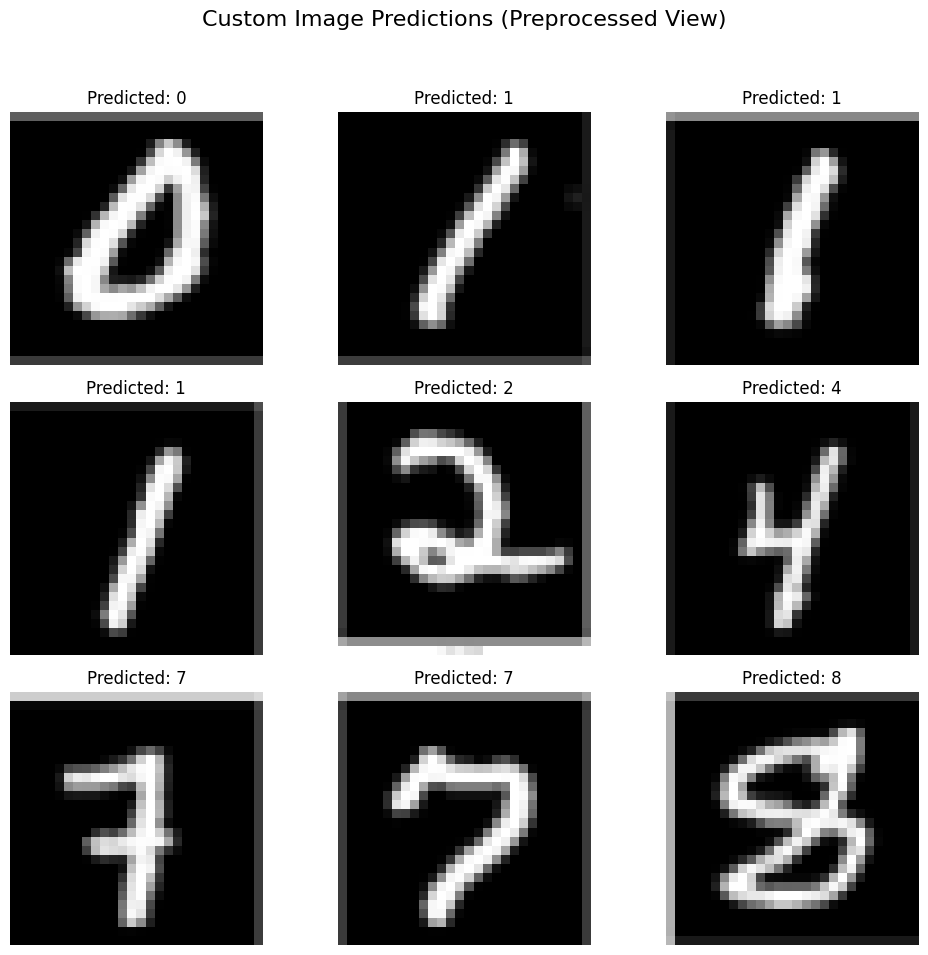


--- Custom Image Prediction Results ---
Image: 0.png, Predicted Digit: 0
Image: 1,.png, Predicted Digit: 1
Image: 1..png, Predicted Digit: 1
Image: 1.png, Predicted Digit: 1
Image: 2.png, Predicted Digit: 2
Image: 4.png, Predicted Digit: 4
Image: 7..png, Predicted Digit: 7
Image: 7.png, Predicted Digit: 7
Image: 8.png, Predicted Digit: 8


In [12]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# List of custom image paths (assuming they are in /content/)
custom_image_paths = [
    '/content/0.png',
    '/content/1,.png',
    '/content/1..png',
    '/content/1.png',
    '/content/2.png',
    '/content/4.png',
    '/content/7..png',
    '/content/7.png',
    '/content/8.png'

]

def preprocess_custom_image(image_path):
    # Load the image
    img = Image.open(image_path).convert('L') # Convert to grayscale
    # Resize to 28x28
    img = img.resize((28, 28))
    # Convert to numpy array and normalize
    img_array = np.asarray(img).astype('float32') / 255.0

    # --- IMPORTANT: MNIST images have WHITE digits on a BLACK background. --- #
    # --- If your custom images have DARK digits on a LIGHT background,      --- #
    # --- uncomment the line below to invert the colors:                     --- #
    # img_array = 1.0 - img_array # Invert colors

    # Reshape for model input (add channel and batch dimensions)
    model_input = np.expand_dims(img_array, axis=-1)
    model_input = np.expand_dims(model_input, axis=0)

    return img_array, model_input # Return both for display and prediction

plt.figure(figsize=(10, 10)) # Adjusted figure size for a 3x3 grid
predictions = []

for i, image_path in enumerate(custom_image_paths):
    preprocessed_img_display, processed_image_for_model = preprocess_custom_image(image_path)
    prediction = model.predict(processed_image_for_model, verbose=0) # verbose=0 to suppress per-image output
    predicted_class = np.argmax(prediction)
    predictions.append((image_path, predicted_class))

    # Display the preprocessed image and prediction
    plt.subplot(3, 3, i + 1) # Changed subplot grid to 3x3
    plt.imshow(preprocessed_img_display, cmap='gray')
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')

plt.suptitle('Custom Image Predictions (Preprocessed View)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Custom Image Prediction Results ---")
for image_path, predicted_class in predictions:
    print(f"Image: {os.path.basename(image_path)}, Predicted Digit: {predicted_class}")

### Summary of Work Accomplished

1.  **Dataset Loading (Step 1):** We successfully loaded the MNIST dataset, understanding its structure and content.
2.  **Data Preprocessing (Step 2):** We preprocessed the data by normalizing pixel values, reshaping images for CNN input, and one-hot encoding the labels.
3.  **Model Building (Step 3):** We built a Convolutional Neural Network (CNN) model using `Conv2D`, `MaxPooling2D`, `Dropout`, `Flatten`, and `Dense` layers, compiling it with the `adam` optimizer and `categorical_crossentropy` loss.
4.  **Model Training (Step 4):** The CNN model was trained for 10 epochs, showing strong learning and convergence.
5.  **Model Evaluation (Step 5):** The model achieved an impressive **Test Accuracy of 99.35%** and a Test Loss of 0.0252, significantly exceeding the initial goal of 98% accuracy.
6.  **Custom Image Testing (Step 6):** We successfully tested the model with custom handwritten digit images, and the model accurately predicted the digits from your uploaded images, further validating its performance.

Overall, the project has successfully developed and validated a high-performing CNN for handwritten digit classification!